In [1]:
from tensorflow.keras.datasets import fashion_mnist
df = fashion_mnist.load_data()

In [2]:
(train_images,train_label),(test_images,test_label) = df

In [3]:
class_name = ['T-shirt/top','Trouser','Pullover',
              'Dress','Coat','Sandal','Shirt','Sneaker','Bag','Ankle boot']

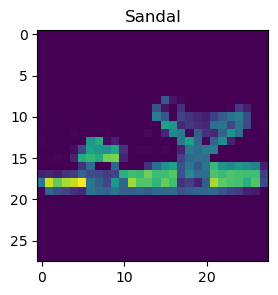

In [4]:
import matplotlib.pyplot as plt
plt.figure(figsize=(4,3))
plt.imshow(train_images[-1])
plt.title(class_name[train_label[-1]])
plt.show()

0
1
2
3
4
5
6
7
8
9


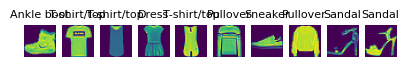

10
11
12
13
14
15
16
17
18
19


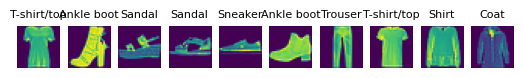

20
21
22
23
24
25
26
27
28
29


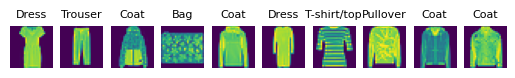

30
31
32
33
34
35
36
37
38
39


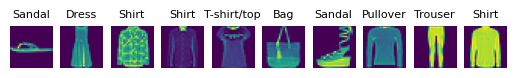

In [5]:
n_rows=4
n_cols=10
plt.figure(figsize=(n_rows * 1.2, n_cols *1.2))
for row in range(n_rows):
    for col in range(n_cols):
        index = n_cols * row + col
        print(index) 
        plt.subplot(n_rows,n_cols, index + 1)
        plt.imshow(train_images[index])
        plt.title(class_name[train_label[index]], fontsize = 8)
        plt.axis('off')
    plt.subplots_adjust(wspace= 0.2, hspace = 0.6)
    plt.axis('off')
    plt.show()


In [32]:
#normalize and rescale the images
train_images_scaled = train_images.reshape((60000,28,28,1))/255.0
test_images_scaled = test_images.reshape((10000,28,28,1))/255.0

In [24]:
# CNN architecture
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D, MaxPooling2D, Flatten, Dropout
cnn_model = Sequential()
cnn_model.add(Conv2D(100, (3,3), activation='relu', input_shape=(28,28,1)))
cnn_model.add(MaxPooling2D((2,2)))
cnn_model.add(Conv2D(50, (3,3), activation='relu'))
cnn_model.add(MaxPooling2D((2,2)))
#cnn_model.add(Conv2D(128, (3,3), activation='relu'))
#Flatten
cnn_model.add(Flatten())
#Dense Layer
cnn_model.add(Dense(50, activation='relu'))
cnn_model.add(Dropout(0.5))
cnn_model.add(Dense(10, activation='softmax'))
cnn_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 26, 26, 100)    │         1,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 13, 13, 100)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 11, 11, 50)     │        45,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 5, 5, 50)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 1250)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 50)             │        62,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │           510 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,110 (426.21 KB)

 Trainable params: 109,110 (426.21 KB)

 Non-trainable params: 0 (0.00 B)

In [25]:
cnn_model.compile(loss = 'sparse_categorical_crossentropy', 
                  optimizer = 'adam',
                  metrics = ['accuracy'])

In [26]:
from tensorflow.keras.callbacks import EarlyStopping
early_stp = EarlyStopping(monitor = 'val_accuracy', patience = 5)

In [27]:
history = cnn_model.fit(train_images_scaled, train_label, 
                        epochs = 10, batch_size = 64, validation_split =0.2, callbacks = [early_stp])

Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 18s 24ms/step - accuracy: 0.7183 - loss: 0.7873 - val_accuracy: 0.8479 - val_loss: 0.4286
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 19s 25ms/step - accuracy: 0.8131 - loss: 0.5164 - val_accuracy: 0.8744 - val_loss: 0.3567
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 19s 25ms/step - accuracy: 0.8359 - loss: 0.4570 - val_accuracy: 0.8829 - val_loss: 0.3239
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 19s 25ms/step - accuracy: 0.8516 - loss: 0.4204 - val_accuracy: 0.8871 - val_loss: 0.3124
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 19s 25ms/step - accuracy: 0.8576 - loss: 0.3970 - val_accuracy: 0.8920 - val_loss: 0.2961
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 19s 25ms/step - accuracy: 0.8646 - loss: 0.3724 - val_accuracy: 0.8963 - val_loss: 0.2853
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 19s 25ms/step - accuracy: 0.8706 - loss: 0.3597 - val_accuracy: 0.8982 - val_loss: 0.2786
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 19s 26ms/step - accuracy: 0.8765 - loss: 0.3409 - 

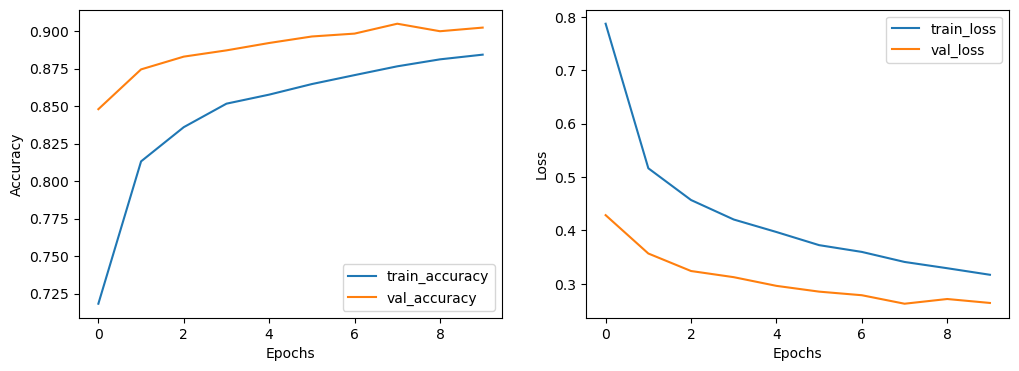

In [28]:
# accuracy and loss curves
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='train_accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

In [33]:
#Evaluate the model
cnn_model.evaluate(test_images_scaled, test_label)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8971 - loss: 0.2857


[0.2857089340686798, 0.8970999717712402]

In [34]:
x_new = test_images_scaled[:3]
prediction = cnn_model.predict(x_new)
print(prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
[[1.3398988e-12 4.5417900e-17 6.3201787e-15 4.2799767e-13 3.8577044e-15
  9.2556593e-06 1.3494953e-13 1.9951200e-05 1.7541729e-12 9.9997079e-01]
 [1.1483722e-05 1.5047008e-12 9.9818617e-01 6.1475134e-08 8.6407922e-04
  3.9962724e-13 9.3813526e-04 8.0893925e-15 5.1031583e-09 1.1002870e-13]
 [4.5916399e-14 1.0000000e+00 2.9732707e-19 5.7052814e-11 2.4298554e-13
  1.3684077e-16 1.7491188e-16 2.7817689e-22 4.1135075e-15 8.5793875e-19]]


In [37]:
# prediction using for loop for first 10 test images

import numpy as np
predictions = []
for i in range(10):
    img = test_images_scaled[i].reshape(1,28,28,1)
    pred = cnn_model.predict(img)
    predictions.append(pred)
predictions = np.array(predictions).squeeze()
predicted_labels = np.argmax(predictions, axis=1)
print(predicted_labels)
print(test_label[:10])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
[9 2 1 1 6 1 4 6 5 7]
[9 2 1 1 6 1 4 6 5 7]


In [38]:
#save the model
cnn_model.save('Fashion_CNN_MOdel_v1.keras')